In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import itertools
from auction_module.bundling_and_bidding.fitness_functions.vrp_learn.distance import (
    my_convex_hull_jaccard_distance,
    my_hausdorff_distance,
    my_modified_hausdorff_distance,
)
import numpy as np
import plotnine as p9


## Plotting and evaluation

In [2]:
path = 'data/experiments/new_experiments/new_experiments_2026-05-26T20:07:37.parquet'
q = pl.scan_parquet(path)
schema = pl.read_parquet_schema(path)
schema

Schema([('meta__start', Datetime(time_unit='ns', time_zone=None)),
        ('meta__run_id', String),
        ('meta__base_seed', Int64),
        ('meta__trial_index', Int64),
        ('meta__status', String),
        ('meta__end', Datetime(time_unit='ns', time_zone=None)),
        ('params__x_min', Int64),
        ('params__x_max', Int64),
        ('params__y_min', Int64),
        ('params__y_max', Int64),
        ('params__size_auction_pool', Int64),
        ('params__num_bundles', Int64),
        ('params__true_num_locations', Int64),
        ('params__pred_num_locations', Int64),
        ('params__opt_algorithm', Int64),
        ('params__maxeval', Int64),
        ('params__seed', UInt64),
        ('res__xopt', List(List(Float64))),
        ('res__opt_val', Float64),
        ('res__return_code', Int64),
        ('res__trajectory', List(List(List(Float64)))),
        ('res__proxy_objectives', List(Float64)),
        ('res__true_objectives',
         List(Struct({'my_convex_hull_jacca

In [3]:
q.select('meta__trial_index').collect()

meta__trial_index
i64
0
1
2
3
4
…
195
196
197


In [4]:
# 1. Create a matching list of iteration indices [0, 1, 2... N] for each row
tidy_lazy = q.with_columns(
    pl.int_ranges(0, pl.col("res__proxy_objectives").list.len()).alias("iteration")
)

# 2. Explode all three list columns in parallel (vertically)
tidy_lazy = tidy_lazy.explode([
    "iteration", 
    "res__proxy_objectives", 
    "res__true_objectives"
])

# 3. Unnest the struct column to make the true metrics top-level columns
df_tidy = tidy_lazy.unnest("res__true_objectives").collect()

# Look at the result
print(df_tidy.head())

shape: (5, 26)
┌───────────┬───────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬──────────┐
│ meta__sta ┆ meta__run ┆ meta__bas ┆ meta__tri ┆ … ┆ my_convex ┆ my_hausdo ┆ my_modifi ┆ iteratio │
│ rt        ┆ _id       ┆ e_seed    ┆ al_index  ┆   ┆ _hull_jac ┆ rff_dista ┆ ed_hausdo ┆ n        │
│ ---       ┆ ---       ┆ ---       ┆ ---       ┆   ┆ card_dist ┆ nce       ┆ rff_dista ┆ ---      │
│ datetime[ ┆ str       ┆ i64       ┆ i64       ┆   ┆ anc…      ┆ ---       ┆ nce       ┆ i64      │
│ ns]       ┆           ┆           ┆           ┆   ┆ ---       ┆ f64       ┆ ---       ┆          │
│           ┆           ┆           ┆           ┆   ┆ f64       ┆           ┆ f64       ┆          │
╞═══════════╪═══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪══════════╡
│ 2026-05-2 ┆ afd760b1e ┆ 1         ┆ 0         ┆ … ┆ 1.0       ┆ 54.194226 ┆ 45.119758 ┆ 0        │
│ 6 17:22:0 ┆ ebed718   ┆           ┆           ┆   ┆           ┆           

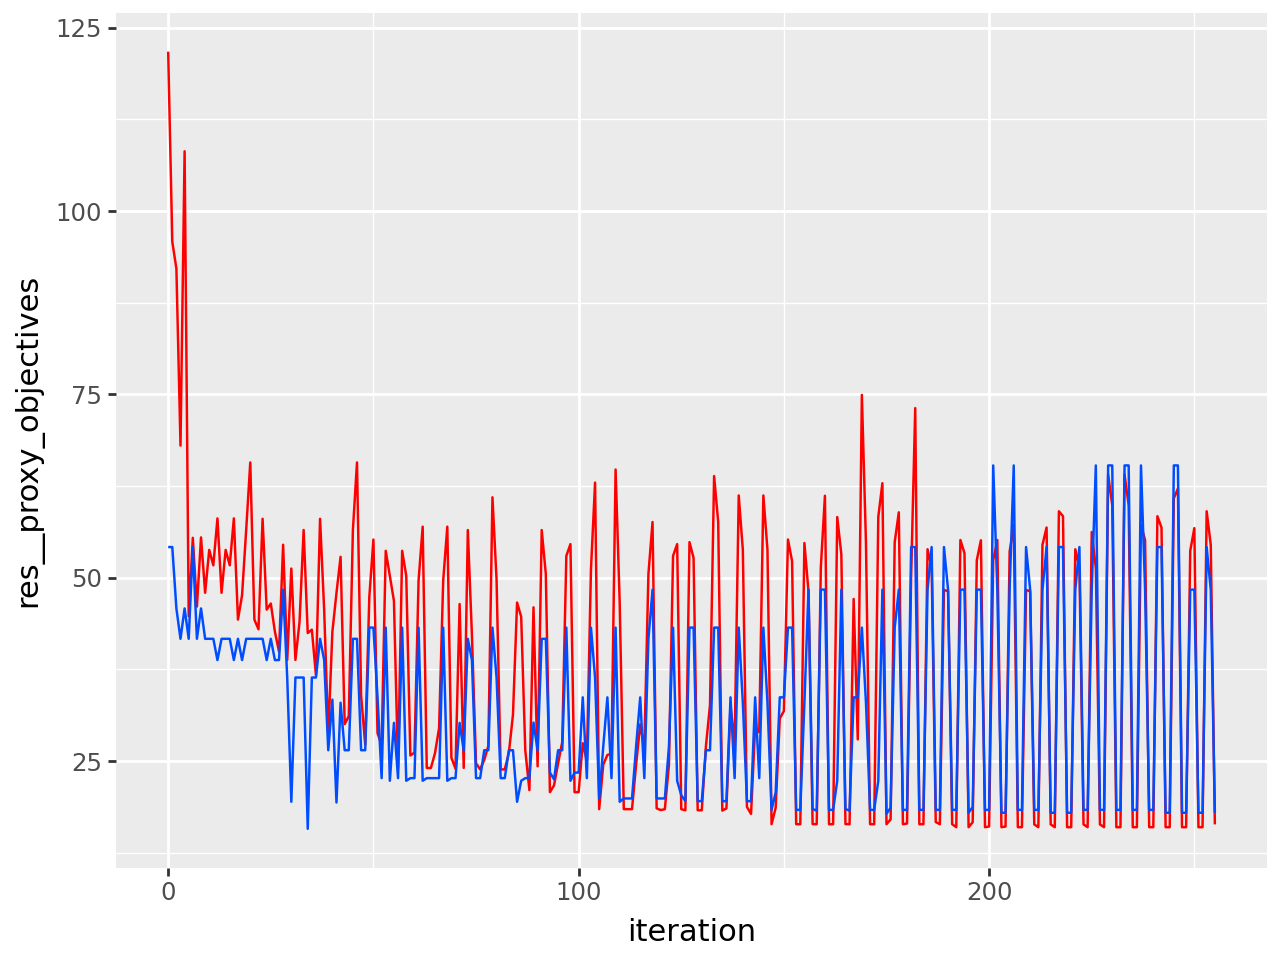

In [5]:
p = (
    p9.ggplot(
        df_tidy.filter(pl.col("meta__trial_index") == 0),
        p9.aes(x="iteration"),
    )
    + p9.geom_line(mapping=p9.aes(y="res__proxy_objectives"), color='#ff0000')
    + p9.geom_line(mapping=p9.aes(y="my_hausdorff_distance"),  color='#004cff')
)
p

In [6]:
# Group by iteration and calculate the mean for all numeric metric columns
df_average = (
    df_tidy.group_by("iteration")
    .agg(
        pl.col("res__proxy_objectives").mean(),
        pl.col("my_convex_hull_jaccard_distance").mean(),
        pl.col("my_hausdorff_distance").mean(),
        pl.col("my_modified_hausdorff_distance").mean(),
    )
    .sort("iteration")
)

print(df_average.head())

shape: (5, 5)
┌───────────┬─────────────────────┬─────────────────────┬─────────────────────┬────────────────────┐
│ iteration ┆ res__proxy_objectiv ┆ my_convex_hull_jacc ┆ my_hausdorff_distan ┆ my_modified_hausdo │
│ ---       ┆ es                  ┆ ard_distanc…        ┆ ce                  ┆ rff_distance       │
│ i64       ┆ ---                 ┆ ---                 ┆ ---                 ┆ ---                │
│           ┆ f64                 ┆ f64                 ┆ f64                 ┆ f64                │
╞═══════════╪═════════════════════╪═════════════════════╪═════════════════════╪════════════════════╡
│ 0         ┆ 121.050734          ┆ 1.0                 ┆ 53.222486           ┆ 38.467751          │
│ 1         ┆ 91.890561           ┆ 1.0                 ┆ 48.319689           ┆ 32.438893          │
│ 2         ┆ 92.886467           ┆ 1.0                 ┆ 49.926044           ┆ 33.785078          │
│ 3         ┆ 73.368731           ┆ 0.949505            ┆ 45.582561          

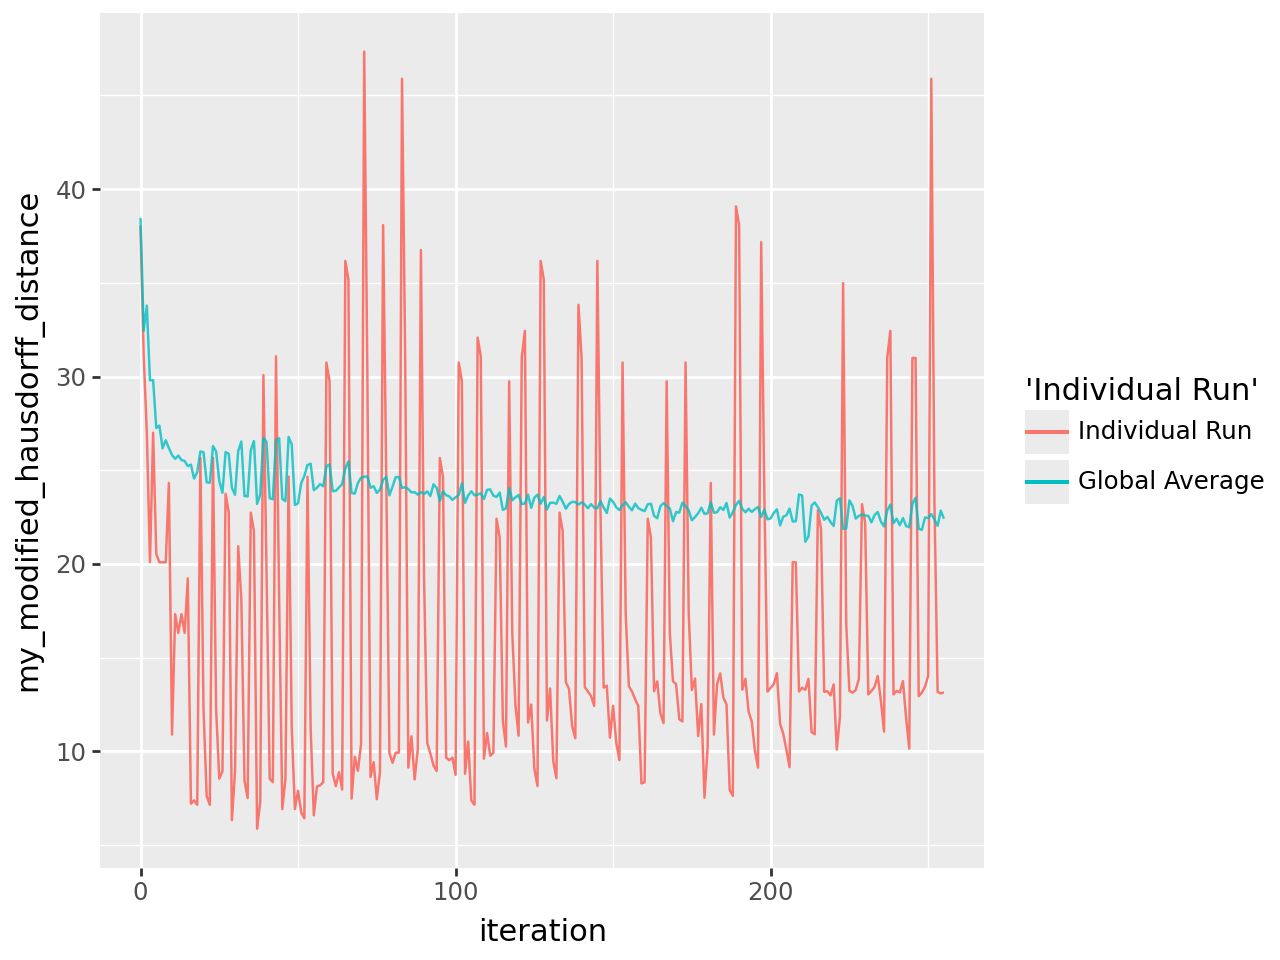

In [ ]:
# 1. Choose the specific run ID you want to look at
target_trial_index = 1  # Replace with one of your actual meta__run_id values
target_y = 'my_modified_hausdorff_distance'

# 2. Filter the tidy data for just this run and convert both to Pandas
df_single_run = df_tidy.filter(
    pl.col("meta__trial_index") == target_trial_index
)  # .to_pandas()

# 3. Build the plotnine visualization
plot = (
    p9.ggplot()
    # Layer 1: The Individual Run (mapped to Blue)
    + p9.geom_line(
        data=df_single_run,
        mapping=p9.aes(
            x="iteration", y=target_y, color="'Individual Run'"
        ),
        # size=1
    )
    # Layer 2: The Global Average (Thicker line, mapped to Red)
    + p9.geom_line(
        data=df_average,
        mapping=p9.aes(
            x="iteration", y=target_y, color="'Global Average'"
        ),
        # size=1.8,
        alpha=0.8,
    )
)

# 4. Display or save the plot
plot
# To save it to disk, uncomment the line below:
# plot.save("optimization_performance.png", width=8, height=5, dpi=300)

In [34]:
no_opt_df.describe()

,idx,my_hausdorff_distance,my_modified_hausdorff_distance,my_convex_hull_jaccard_distance,normalized hausdorff,normalized modified hausdorff
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,50.611637,30.692869,0.842863,0.357878,0.217031
std,288.819436,13.574185,8.447569,0.146827,0.095984,0.059733
min,0.000000,16.973671,10.464778,0.341683,0.120022,0.073997
25%,249.750000,40.297506,24.674876,0.752052,0.284946,0.174478
50%,499.500000,50.112245,29.996357,0.880112,0.354347,0.212106
75%,749.250000,59.574669,35.828583,0.967648,0.421257,0.253346
max,999.000000,95.162553,67.046465,1.000000,0.672901,0.474090


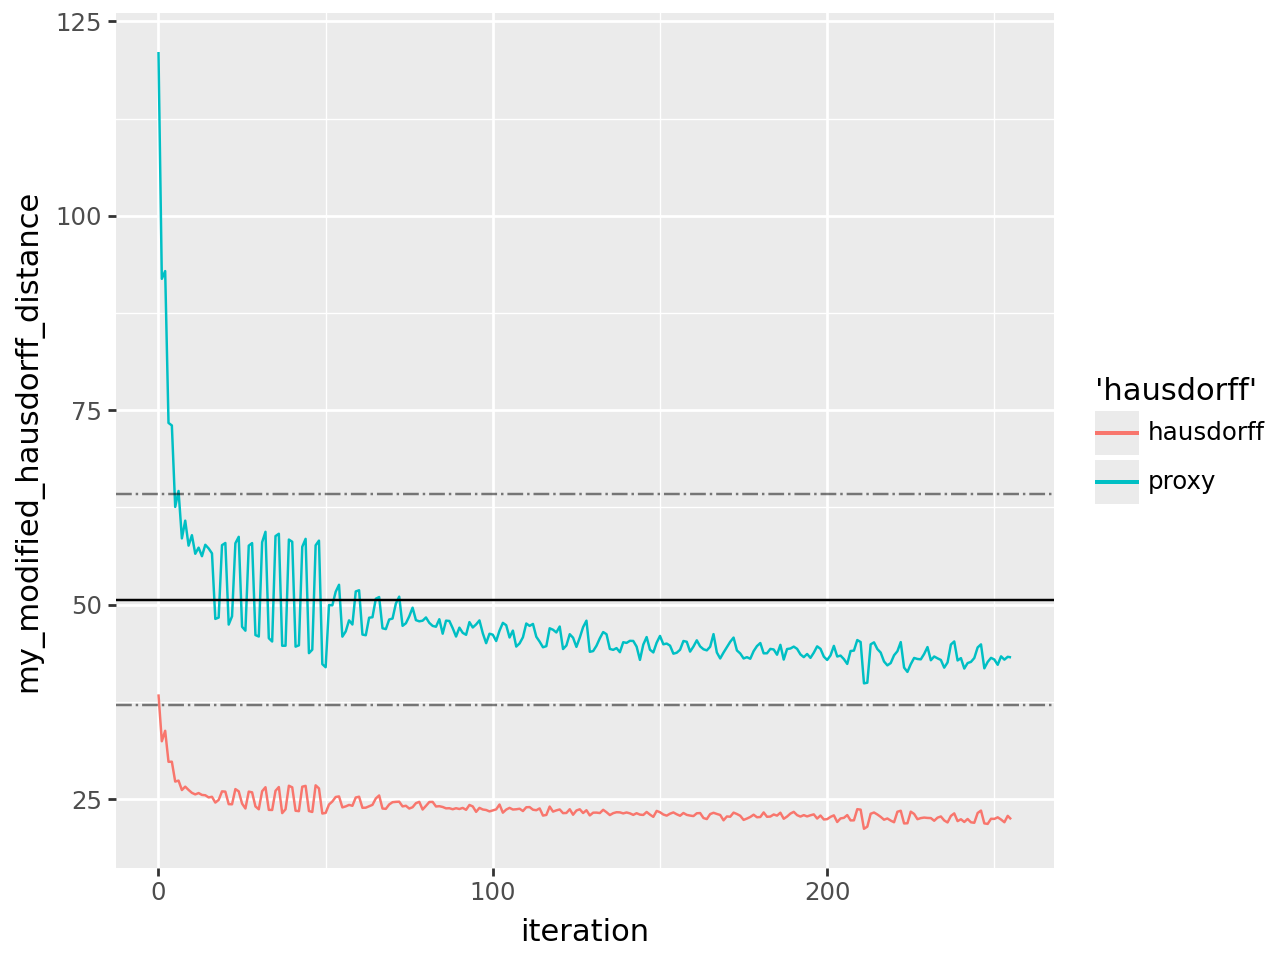

In [33]:
# (proxy and) hausdorff of n random samples: the no-optmization benchmark
num_samples = 1000
records = []
rng = np.random.default_rng(1)
x_min, y_min, x_max, y_max = 0, 0, 100, 100
true_num_base_locations, pred_num_base_locations = 4, 4

for i in range(num_samples):
    true_base_locations = rng.uniform((x_min, y_min), (x_max, y_max), size=(true_num_base_locations, 2))
    pred_base_locations = rng.uniform((x_min, y_min), (x_max, y_max), size=(pred_num_base_locations, 2))
    # df = pd.DataFrame(np.concat([set_a, set_b], axis=0), columns=['x', 'y'])
    record = {
        'idx': i,
        'true_base_locations':true_base_locations,
        'pred_base_locations': pred_base_locations,
        'my_hausdorff_distance': my_hausdorff_distance(true_base_locations, pred_base_locations),
        'my_modified_hausdorff_distance': my_modified_hausdorff_distance(true_base_locations, pred_base_locations),
        'my_convex_hull_jaccard_distance': my_convex_hull_jaccard_distance(true_base_locations, pred_base_locations),
    }
    record['normalized hausdorff'] = record['my_hausdorff_distance']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
    record['normalized modified hausdorff'] = record['my_modified_hausdorff_distance']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
    records.append(record)
no_opt_df = pd.DataFrame.from_records(records)

(
    p9.ggplot()
    + p9.geom_line(data=df_average, mapping=p9.aes(x='iteration', y='my_modified_hausdorff_distance', color="'hausdorff'"))
    + p9.geom_line(data=df_average, mapping=p9.aes(x='iteration', y='res__proxy_objectives', color="'proxy'"))
    + p9.geom_hline(yintercept = no_opt_df['my_hausdorff_distance'].mean())
    + p9.geom_hline(yintercept = no_opt_df['my_hausdorff_distance'].mean() + no_opt_df['my_hausdorff_distance'].std(), alpha=0.5, linetype='-.')
    + p9.geom_hline(yintercept = no_opt_df['my_hausdorff_distance'].mean() - no_opt_df['my_hausdorff_distance'].std(), alpha=0.5, linetype='-.')
    # +p9.scale_y_log10()
)

In [9]:
metric_x = 'res__proxy_objectives'
metric_y = 'my_modified_hausdorff_distance'

# Group by iteration and calculate all the statistics at once
df_trajectory = (
    df_tidy.group_by("iteration")
    .agg(
        pl.col(metric_x).mean().alias("x_mean"),
        pl.col(metric_x).std().alias("x_std"),
        pl.col(metric_y).mean().alias("y_mean"),
        pl.col(metric_y).std().alias("y_std")
    )
    .with_columns(
        (pl.col("x_mean") - pl.col("x_std")).alias("x_min"),
        (pl.col("x_mean") + pl.col("x_std")).alias("x_max"),
        (pl.col("y_mean") - pl.col("y_std")).alias("y_min"),
        (pl.col("y_mean") + pl.col("y_std")).alias("y_max"),
    )
    .sort("iteration")
    # .to_pandas()  # Convert to Pandas for plotnine compatibility
)

In [10]:
df_trajectory.head()

iteration,x_mean,x_std,y_mean,y_std,x_min,x_max,y_min,y_max
i64,f64,f64,f64,f64,f64,f64,f64,f64
0,121.050734,32.444551,38.467751,6.878653,88.606183,153.495286,31.589099,45.346404
1,91.890561,27.704955,32.438893,7.285602,64.185606,119.595516,25.153291,39.724495
2,92.886467,27.890573,33.785078,6.959011,64.995893,120.77704,26.826067,40.74409
3,73.368731,23.031819,29.796414,7.262443,50.336912,96.400551,22.533971,37.058858
4,73.040332,23.576486,29.810704,7.321225,49.463846,96.616818,22.489479,37.13193


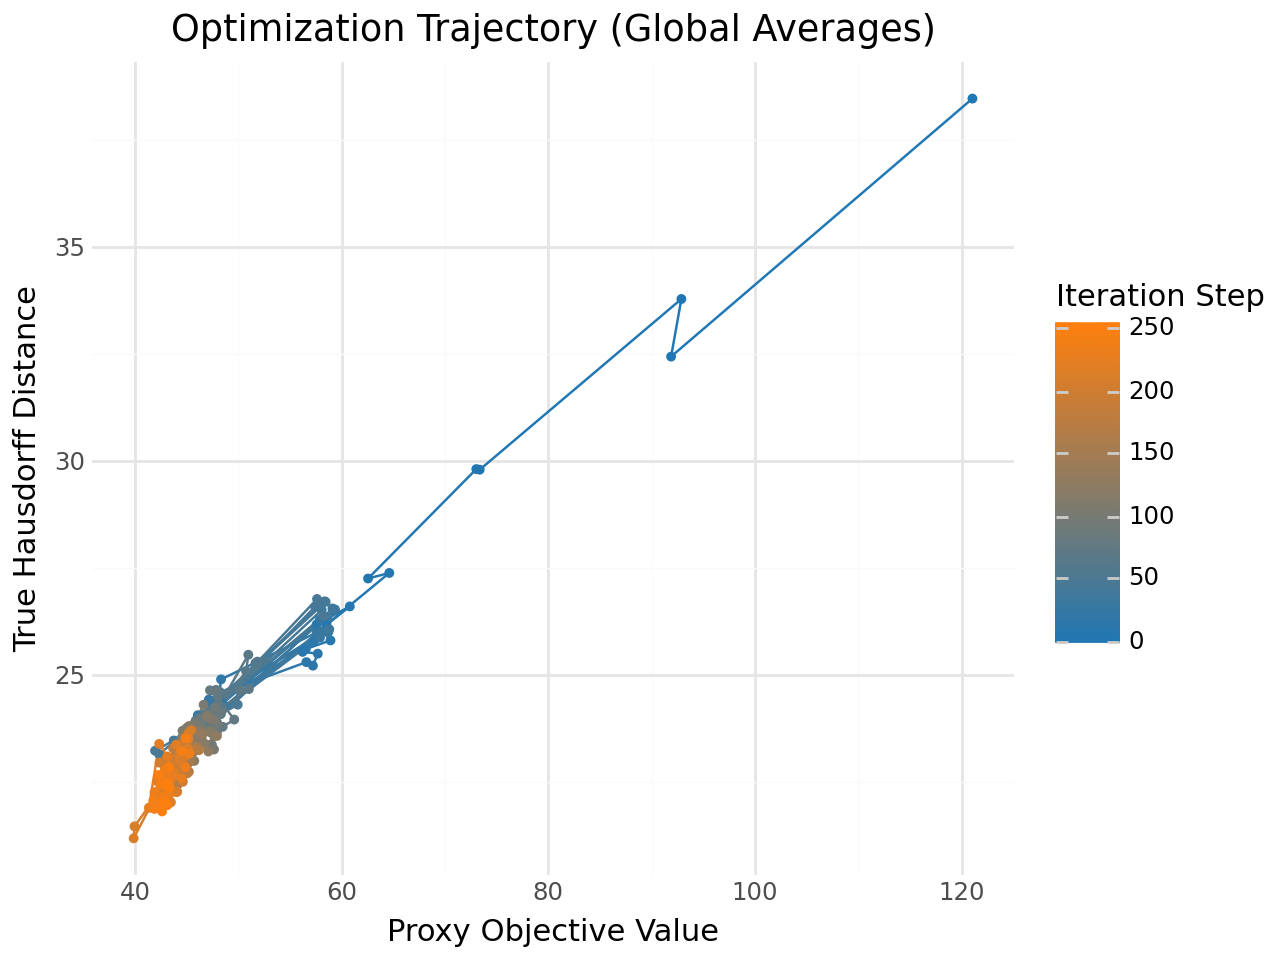

In [52]:
plot = (
    p9.ggplot(df_trajectory, p9.aes(x="x_mean", y="y_mean"))
    
    # 1. Background variance bars (Vertical & Horizontal SD)
    # + p9.geom_errorbar(
    #     p9.aes(ymin="y_min", ymax="y_max"), 
    #     color="#d3d3d3", 
    #     alpha=0.6,
    #     width=0.2 # small cap width
    # )
    # + p9.geom_errorbarh(
    #     p9.aes(xmin="x_min", xmax="x_max"), 
    #     color="#d3d3d3", 
    #     alpha=0.6,
    #     height=0.2
    # )
    
    # 2. Chronological timeline path
    + p9.geom_path(
        p9.aes(color="iteration"), 
        # size=1.5
        # alpha=0.3
    )
    + p9.geom_point(
        p9.aes(color="iteration"), 
        size=1,
        # alpha=0.3
    )
    
    # 3. Styling & Labels
    # Transitions color from Blue (Start) to Orange (End)
    + p9.scale_color_gradient(low="#1f77b4", high="#ff7f0e") 
    + p9.labs(
        title="Optimization Trajectory (Global Averages)",
        x="Proxy Objective Value",
        y="True Hausdorff Distance",
        color="Iteration Step"
    )
    + p9.theme_minimal()
    # + p9.xlim(None, 80)
    # + p9.ylim(None, 30)
    # + p9.scale_y_log10()
    # + p9.scale_x_log10()
)

plot

## old

In [8]:
# create some additional metrics for plotting
plot_obj_name = 'my_hausdorff_distance'
proxy = df['res__proxy_objectives']
proxy

0      [121.75051334594035, 95.83644922470782, 92.162...
1      [173.01571460419427, 145.16327014778912, 122.6...
2      [130.24544137895958, 91.03364762547967, 103.93...
3      [149.55141256437534, 113.67854898792471, 104.7...
4      [65.95216069242917, 58.36576479409826, 48.8505...
                             ...                        
195    [125.2327832478381, 94.70645437350086, 89.7176...
196    [96.82361540450759, 69.24277940695333, 68.4657...
197    [114.45932683709091, 71.54849753838302, 89.160...
198    [66.75983073675367, 47.10294576775427, 53.9067...
199    [125.4364879132065, 85.86326339011347, 86.1698...
Name: res__proxy_objectives, Length: 200, dtype: object

In [ ]:
true_obj = [x[plot_obj_name] for x in res['true_objectives']]
# minimum proxy so far
proxy_running_min = list(itertools.accumulate(proxy, min))
# hausdorff at the minimum proxy
# Zip both lists, then track the running minimum based on proxy
running_min_with_hausdorff = itertools.accumulate(
    zip(proxy, true_obj), 
    lambda current, next_item: next_item if next_item[0] < current[0] else current
)
# Extract only the corresponding 'foo' values
hausdorff_following_min = [item[1] for item in running_min_with_hausdorff]

# (proxy and) hausdorff of n random samples: the no-optmization benchmark
num_samples = 1000
records = []
rng = np.random.default_rng(1)
for i in range(num_samples):
    true_base_locations = rng.uniform((x_min, y_min), (x_max, y_max), size=(true_num_locations, 2))
    pred_base_locations = rng.uniform((x_min, y_min), (x_max, y_max), size=(pred_num_locations, 2))
    # df = pd.DataFrame(np.concat([set_a, set_b], axis=0), columns=['x', 'y'])
    record = {
        'idx': i,
        'true_base_locations':true_base_locations,
        'pred_base_locations': pred_base_locations,
        'my_hausdorff_distance': my_hausdorff_distance(true_base_locations, pred_base_locations),
        'my_modified_hausdorff_distance': my_modified_hausdorff_distance(true_base_locations, pred_base_locations),
        'my_convex_hull_jaccard_distance': my_convex_hull_jaccard_distance(true_base_locations, pred_base_locations),
    }
    record['normalized hausdorff'] = record['my_hausdorff_distance']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
    record['normalized modified hausdorff'] = record['my_modified_hausdorff_distance']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
    records.append(record)
no_opt_df = pd.DataFrame.from_records(records)



In [ ]:
_proxy_objectives']
true_obj = [x[plot_obj_name] for x in res['true_objectives']]
# minimum proxy so far
proxy_running_min = list(itertools.accumulate(proxy, min))
# hausdorff at the minimum proxy
# Zip both lists, then track the running minimum based on proxy
running_min_with_hausdorff = itertools.accumulate(
    zip(proxy, true_obj), 
    lambda current, next_item: next_item if next_item[0] < current[0] else current
)
# Extract only the corresponding 'foo' values
hausdorff_following_min = [item[1] for item in running_min_with_hausdorff]

# (proxy and) hausdorff of n random samples: the no-optmization benchmark
num_samples = 1000
records = []
rng = np.random.default_rng(1)
for i in range(num_samples):
    true_base_locations = rng.uniform((x_min, y_min), (x_max, y_max), size=(true_num_locations, 2))
    pred_base_locations = rng.uniform((x_min, y_min), (x_max, y_max), size=(pred_num_locations, 2))
    # df = pd.DataFrame(np.concat([set_a, set_b], axis=0), columns=['x', 'y'])
    record = {
        'idx': i,
        'true_base_locations':true_base_locations,
        'pred_base_locations': pred_base_locations,
        'my_hausdorff_distance': my_hausdorff_distance(true_base_locations, pred_base_locations),
        'my_modified_hausdorff_distance': my_modified_hausdorff_distance(true_base_locations, pred_base_locations),
        'my_convex_hull_jaccard_distance': my_convex_hull_jaccard_distance(true_base_locations, pred_base_locations),
    }
    record['normalized hausdorff'] = record['my_hausdorff_distance']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
    record['normalized modified hausdorff'] = record['my_modified_hausdorff_distance']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
    records.append(record)
no_opt_df = pd.DataFrame.from_records(records)



In [ ]:
plt.plot(proxy, 'b', label='Proxy', markersize=3, alpha=0.3)
plt.plot(proxy_running_min, 'b--', label='proxy running min', markersize=3, )
plt.plot(true_obj, 'r', label=plot_obj_name, markersize=3, alpha=0.3)
plt.plot(hausdorff_following_min, 'r--', label=f'{plot_obj_name} following min proxy',)
plt.boxplot(no_opt_df[plot_obj_name], positions=[len(proxy)], widths=10, label=f'no-opt {plot_obj_name} (boxplot)')
plt.hlines(no_opt_df[plot_obj_name].mean(), 0, len(proxy), linestyles='-.', label=f'no-opt {plot_obj_name} (mean)')
# plt.yscale('log')
plt.legend()

In [ ]:
# plot the trajectory of points
foo = np.array(res["trajectory"])
t, n, d = foo.shape
for i in range(n):
    x = foo[:, i, 0]
    y = foo[:, i, 1]
    plt.plot(
        x, # + rng.normal(0, 2, x.shape),  # jitter for e.g. DIRECT
        y, #+ rng.normal(0, 2, y.shape),
        "-o", 
        alpha=0.3
    )
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    if i > 4:
        break

In [ ]:
plt.plot(res['trajectory'][0][:, 0], 
res['trajectory'][0][:, 1], 'o')

In [ ]:
res['trajectory'][-1][:, 0], res['trajectory'][-1][:, 1]

## Scratches

In [ ]:
from functools import cache
from time import sleep

@cache
def bar_internal(x: np.array):
    sleep(2)
    return sum(x)

def bar(x):
    normalized_input=tuple(sorted(x))
    return bar_internal(np.array(normalized_input))

In [ ]:
bar((1, 2, 3, 4, 5))

In [ ]:
bar((5, 4, 3, 2, 5))

In [ ]:
bar((5, 4, 3, 2, 1))

In [ ]:
doo = np.array([0, 0, 3, 4, 3, 1, 1, 2])
doo = doo.reshape(-1, 2, copy=True)

In [ ]:
doo

In [ ]:
ind = np.lexsort([doo[:, 1], doo[:, 0]])
doo[ind]

In [ ]:
goo = np.array([0, 0, 3, 4, 3, 1, 1, 2])
structured_goo = goo.view(dtype=[('f0', goo.dtype), ('f1', goo.dtype)])
sorted_goo = np.sort(structured_goo, order=['f0', 'f1'])
sorted_goo

In [ ]:
sorted(((0, 0), (3, 4), (3, 1), (1, 2)))

In [ ]:
from new_experiments import solve_tsp_pyvrp
from pyvrp.stop import MaxRuntime
rng2 = np.random.default_rng(2)
locations = rng2.uniform(0, 100, size=(20, 2))
min_cost  = solve_tsp_pyvrp(locations, stop=MaxRuntime(10))
print(min_cost)
